# Week 3 — Error analysis

This notebook analyzes where the default LightGBM model adds value over the seasonal naive baseline and where it still fails. Core modeling and backtest logic lives in reusable modules under `src/`; this notebook is only for analysis and visualization.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import polars as pl
import yaml

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.training import backtest  # noqa: E402
from src.training.models import LGBMPredictor  # noqa: E402

PROJECT_ROOT

PosixPath('/Users/nguyenvanquoc/Desktop/bikeshare-forecast')

In [2]:
with open(PROJECT_ROOT / "config" / "config.yaml") as f:
    cfg = yaml.safe_load(f)

df = pl.read_parquet(PROJECT_ROOT / "data" / "processed" / "features.parquet")

eval_windows = backtest.eval_months(df, cfg["backtest"]["n_windows"])
latest_window = backtest.eval_months(df, 1)[0]

print("Evaluation windows:", eval_windows)
print("Latest evaluation window:", latest_window)
print("Feature table shape:", df.shape)


Evaluation windows: ['2026-03', '2026-04', '2026-05', '2026-06']
Latest evaluation window: 2026-06
Feature table shape: (4887672, 24)


## 1. Prediction table

In [3]:
predictors = [
    backtest.SeasonalNaive(),
    LGBMPredictor(
        cfg["model"]["features"],
        cfg["model"]["params"],
        name="lgbm",
    ),
]

preds = backtest.prediction_table(
    features_df=df,
    predictors=predictors,
    window_month=latest_window,
)

err = (
    preds
    .with_columns(
        (pl.col("trips") - pl.col("pred_lgbm")).abs().alias("ae_lgbm"),
        (pl.col("trips") - pl.col("pred_seasonal_naive")).abs().alias("ae_naive"),
        (pl.col("pred_lgbm") - pl.col("trips")).alias("bias_lgbm"),
    )
    .with_columns(
        (pl.col("ae_naive") - pl.col("ae_lgbm")).alias("lgbm_improvement")
    )
)

print(err.shape)
err.head()

(144000, 9)


station_id,hour,trips,pred_seasonal_naive,pred_lgbm,ae_lgbm,ae_naive,bias_lgbm,lgbm_improvement
str,datetime[μs],i32,i32,f64,f64,i32,f64,f64
"""13001""",2026-06-01 00:00:00,0,0,0.545466,0.545466,0,0.545466,-0.545466
"""13001""",2026-06-01 01:00:00,0,3,0.344353,0.344353,3,0.344353,2.655647
"""13001""",2026-06-01 02:00:00,0,0,0.153573,0.153573,0,0.153573,-0.153573
"""13001""",2026-06-01 03:00:00,0,0,0.140029,0.140029,0,0.140029,-0.140029
"""13001""",2026-06-01 04:00:00,0,0,0.166496,0.166496,0,0.166496,-0.166496


In [4]:
output_path = PROJECT_ROOT / "data" / "processed" / f"error_analysis_predictions_{latest_window}.parquet"
err.write_parquet(output_path)
output_path

PosixPath('/Users/nguyenvanquoc/Desktop/bikeshare-forecast/data/processed/error_analysis_predictions_2026-06.parquet')

**Conclusion:** The prediction table contains actual station-hour demand, LightGBM predictions, seasonal naive predictions, absolute errors, and LightGBM bias for the latest evaluation month. This table is the basis for all error-analysis slices below.

## 2. Overall latest-window performance

In [5]:
overall = err.select(
    pl.col("ae_lgbm").mean().alias("lgbm_mae"),
    pl.col("ae_naive").mean().alias("seasonal_naive_mae"),
    pl.col("lgbm_improvement").mean().alias("mae_reduction_vs_naive"),
    (pl.col("bias_lgbm").mean()).alias("mean_bias_lgbm"),
)

overall

lgbm_mae,seasonal_naive_mae,mae_reduction_vs_naive,mean_bias_lgbm
f64,f64,f64,f64
1.425268,1.93659,0.511323,0.07736


In [6]:
overall_row = overall.to_dicts()[0]

latest_lgbm_mae = overall_row["lgbm_mae"]
latest_naive_mae = overall_row["seasonal_naive_mae"]
latest_reduction_pct = (1 - latest_lgbm_mae / latest_naive_mae) * 100

latest_lgbm_mae, latest_naive_mae, latest_reduction_pct

(1.4252677561745752, 1.9365902777777777, 26.403237043508298)

**Conclusion:** In the latest evaluation month, LightGBM achieves an MAE of 1.425 compared with 1.936 for the seasonal naive baseline, reducing MAE by 26.4%. This confirms that the model adds value in the most recent backtest window, not only on the four-window average.

## 3. Error by hour of day

In [7]:
by_hour = (
    err.group_by(pl.col("hour").dt.hour().alias("hour_of_day"))
    .agg(
        pl.col("ae_lgbm").mean().alias("mae_lgbm"),
        pl.col("ae_naive").mean().alias("mae_naive"),
        pl.col("lgbm_improvement").mean().alias("mae_reduction"),
        pl.col("trips").mean().alias("avg_trips"),
        pl.len().alias("n"),
    )
    .with_columns(
        (1 - pl.col("mae_lgbm") / pl.col("mae_naive")).alias("pct_reduction_vs_naive")
    )
    .sort("hour_of_day")
)

by_hour

hour_of_day,mae_lgbm,mae_naive,mae_reduction,avg_trips,n,pct_reduction_vs_naive
i8,f64,f64,f64,f64,u32,f64
0,0.822524,1.0495,0.226976,0.881,6000,0.216271
1,0.558966,0.659167,0.100201,0.525,6000,0.152011
2,0.36986,0.4315,0.06164,0.309667,6000,0.142851
3,0.243091,0.2665,0.023409,0.167333,6000,0.087838
4,0.237706,0.2455,0.007794,0.155167,6000,0.031749
…,…,…,…,…,…,…
19,2.119782,2.825667,0.705885,3.7935,6000,0.249812
20,1.652806,2.1885,0.535694,2.696667,6000,0.244777
21,1.445207,1.939167,0.493959,2.095667,6000,0.254728


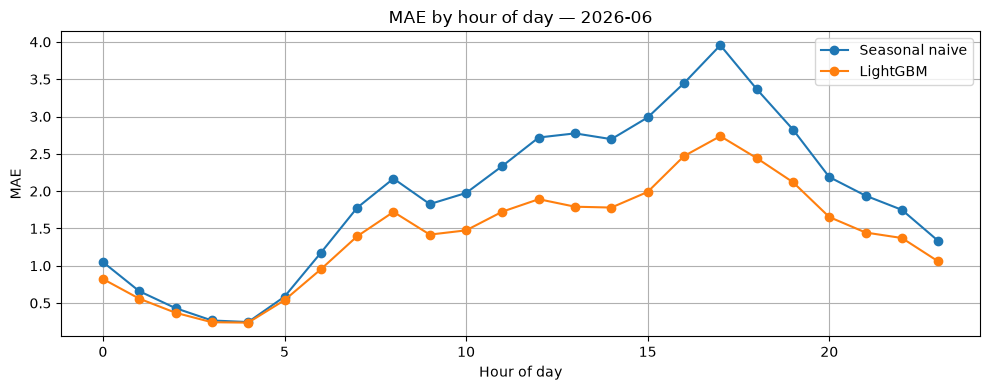

In [8]:
by_hour_pd = by_hour.to_pandas()

plt.figure(figsize=(10, 4))
plt.plot(by_hour_pd["hour_of_day"], by_hour_pd["mae_naive"], marker="o", label="Seasonal naive")
plt.plot(by_hour_pd["hour_of_day"], by_hour_pd["mae_lgbm"], marker="o", label="LightGBM")
plt.xlabel("Hour of day")
plt.ylabel("MAE")
plt.title(f"MAE by hour of day — {latest_window}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
best_hours = by_hour.sort("pct_reduction_vs_naive", descending=True).head(5)
worst_hours = by_hour.sort("pct_reduction_vs_naive").head(5)

best_hours, worst_hours

(shape: (5, 7)
 ┌─────────────┬──────────┬───────────┬───────────────┬───────────┬──────┬────────────────────────┐
 │ hour_of_day ┆ mae_lgbm ┆ mae_naive ┆ mae_reduction ┆ avg_trips ┆ n    ┆ pct_reduction_vs_naive │
 │ ---         ┆ ---      ┆ ---       ┆ ---           ┆ ---       ┆ ---  ┆ ---                    │
 │ i8          ┆ f64      ┆ f64       ┆ f64           ┆ f64       ┆ u32  ┆ f64                    │
 ╞═════════════╪══════════╪═══════════╪═══════════════╪═══════════╪══════╪════════════════════════╡
 │ 13          ┆ 1.791134 ┆ 2.774     ┆ 0.982866      ┆ 3.313     ┆ 6000 ┆ 0.354314               │
 │ 14          ┆ 1.779932 ┆ 2.6965    ┆ 0.916568      ┆ 3.2225    ┆ 6000 ┆ 0.33991                │
 │ 15          ┆ 1.989649 ┆ 2.987667  ┆ 0.998018      ┆ 3.893167  ┆ 6000 ┆ 0.334046               │
 │ 17          ┆ 2.736798 ┆ 3.955667  ┆ 1.218868      ┆ 6.357333  ┆ 6000 ┆ 0.308132               │
 │ 12          ┆ 1.891819 ┆ 2.718667  ┆ 0.826848      ┆ 3.365     ┆ 6000 ┆ 0.304137  

**Conclusion:** Error is strongly structured by hour of day. LightGBM delivers its strongest relative improvements during the daytime and commute-heavy period, especially from 12:00 to 17:00. The largest improvements in the hourly slice occur at 13:00, 14:00, 15:00, 17:00, and 12:00, where LightGBM reduces MAE by 35.4%, 34.0%, 33.4%, 30.8%, and 30.4%, respectively, relative to the seasonal naive baseline.

The model adds the least value during very low-demand overnight hours. At 04:00, 05:00, and 03:00, the MAE reductions are only 3.2%, 8.0%, and 8.8%, respectively. This is expected because overnight demand is already very low and highly zero-inflated, so there is less room for a model to improve over a weekly copy baseline.

## 4. Weekday vs weekend error

In [10]:
by_weekend = (
    err.with_columns(
        (pl.col("hour").dt.weekday() >= 6).alias("is_weekend")
    )
    .group_by("is_weekend")
    .agg(
        pl.col("ae_lgbm").mean().alias("mae_lgbm"),
        pl.col("ae_naive").mean().alias("mae_naive"),
        pl.col("trips").mean().alias("avg_trips"),
        pl.len().alias("n"),
    )
    .with_columns(
        (1 - pl.col("mae_lgbm") / pl.col("mae_naive")).alias("pct_reduction_vs_naive")
    )
    .sort("is_weekend")
)

by_weekend

is_weekend,mae_lgbm,mae_naive,avg_trips,n,pct_reduction_vs_naive
bool,f64,f64,f64,u32,f64
false,1.339253,1.821884,2.410606,105600,0.264908
true,1.661809,2.252031,2.767865,38400,0.262084


**Conclusion:** LightGBM improves over the seasonal naive baseline on both weekdays and weekends. On weekdays, LightGBM reduces MAE from 1.822 to 1.339, a 26.5% improvement. On weekends, it reduces MAE from 2.252 to 1.662, a 26.2% improvement.

The relative improvement is almost identical across weekdays and weekends, which suggests that the model is not only learning commute-driven weekday demand. It also adds value for leisure-driven weekend demand, likely through the combination of calendar, weather, station, and lag features.

## 5. Rainy vs dry hours

In [11]:
# weather slice — rainy vs dry
weather = pl.read_parquet(str(PROJECT_ROOT / "data" / "raw" / "weather" / "historical" / "*.parquet"))

rain_error = (
    err.join(weather.rename({"timestamp": "hour"}), on="hour", how="left")
    .with_columns(
        (pl.col("precipitation") > 0.5).alias("rainy_hour")
    )
    .group_by("rainy_hour")
    .agg(
        pl.col("ae_lgbm").mean().alias("mae_lgbm"),
        pl.col("ae_naive").mean().alias("mae_naive"),
        pl.col("trips").mean().alias("avg_trips"),
        pl.len().alias("n"),
    )
    .with_columns(
        (1 - pl.col("mae_lgbm") / pl.col("mae_naive")).alias("pct_reduction_vs_naive")
    )
    .sort("rainy_hour")
)

rain_error

rainy_hour,mae_lgbm,mae_naive,avg_trips,n,pct_reduction_vs_naive
bool,f64,f64,f64,u32,f64
false,1.447375,1.917323,2.605725,129600,0.245106
true,1.226305,2.11,1.607222,14400,0.418813


**Conclusion:** Weather appears to add meaningful value beyond lag-based demand history. During dry hours, LightGBM reduces MAE from 1.917 to 1.447, a 24.5% improvement relative to seasonal naive. During rainy hours, the improvement is much larger: MAE falls from 2.110 to 1.226, a 41.9% reduction.

This supports keeping precipitation and weather-related features in the model. Seasonal naive cannot react to current weather conditions, while LightGBM can use precipitation, temperature, wind, snowfall, and humidity to adjust demand forecasts. The no-weather experiment on Day 4 should quantify how much performance is lost when these weather features are removed.

## 6. Bias during high-demand station-hours

In [12]:
# bias during high-demand peaks
peak_threshold = err["trips"].quantile(0.95)

peak_bias = (
    err.with_columns(
        (pl.col("trips") >= peak_threshold).alias("top_5pct_demand")
    )
    .group_by("top_5pct_demand")
    .agg(
        pl.col("trips").mean().alias("avg_actual_trips"),
        pl.col("pred_lgbm").mean().alias("avg_pred_lgbm"),
        pl.col("bias_lgbm").mean().alias("mean_bias_lgbm"),
        pl.col("ae_lgbm").mean().alias("mae_lgbm"),
        pl.len().alias("n"),
    )
    .sort("top_5pct_demand")
)

peak_threshold, peak_bias

(9.0,
 shape: (2, 6)
 ┌─────────────────┬──────────────────┬───────────────┬────────────────┬──────────┬────────┐
 │ top_5pct_demand ┆ avg_actual_trips ┆ avg_pred_lgbm ┆ mean_bias_lgbm ┆ mae_lgbm ┆ n      │
 │ ---             ┆ ---              ┆ ---           ┆ ---            ┆ ---      ┆ ---    │
 │ bool            ┆ f64              ┆ f64           ┆ f64            ┆ f64      ┆ u32    │
 ╞═════════════════╪══════════════════╪═══════════════╪════════════════╪══════════╪════════╡
 │ false           ┆ 1.82092          ┆ 2.157488      ┆ 0.336568       ┆ 1.195956 ┆ 135867 │
 │ true            ┆ 13.948481        ┆ 9.695606      ┆ -4.252876      ┆ 5.256074 ┆ 8133   │
 └─────────────────┴──────────────────┴───────────────┴────────────────┴──────────┴────────┘)

**Conclusion:** LightGBM is nearly unbiased on average across all station-hours, but it under-predicts the highest-demand cases. For the top 5% highest-demand station-hours, actual demand averages 13.948 trips, while LightGBM predicts only 9.696 trips on average. This corresponds to a mean bias of -4.253 trips, meaning the model under-predicts peak demand by more than four trips per station-hour.

This matters operationally because under-predicting high-demand station-hours can lead to under-allocation of bikes during the most important rebalancing periods. The model performs well on average, but it is conservative during spikes, which is common for tree-based models optimized for average error.

## 7. Worst stations

In [13]:
# worst stations
station_master = pl.read_parquet(PROJECT_ROOT / "data" / "processed" / "station_master.parquet")

station_error = (
    err.group_by("station_id")
    .agg(
        pl.col("ae_lgbm").mean().alias("mae_lgbm"),
        pl.col("ae_naive").mean().alias("mae_naive"),
        pl.col("trips").mean().alias("avg_trips"),
        pl.col("trips").sum().alias("total_trips"),
        pl.len().alias("n"),
    )
    .with_columns(
        (1 - pl.col("mae_lgbm") / pl.col("mae_naive")).alias("pct_reduction_vs_naive")
    )
    .join(station_master.select(["station_id", "name", "lat", "lng"]), on="station_id", how="left")
    .sort("mae_lgbm", descending=True)
)

station_error.head(20)

station_id,mae_lgbm,mae_naive,avg_trips,total_trips,n,pct_reduction_vs_naive,name,lat,lng
str,f64,f64,f64,i32,u32,f64,str,f64,f64
"""CHI01747""",5.611651,8.356944,14.026389,10099,720,0.328504,"""Navy Pier""",41.892278,-87.612043
"""LF-005""",3.896972,5.843056,8.319444,5990,720,0.333059,"""DuSable Lake Shore Dr & North …",41.911722,-87.626804
"""13300""",3.826927,5.984722,8.277778,5960,720,0.360551,"""DuSable Lake Shore Dr & Monroe…",41.880958,-87.616743
"""13042""",3.167219,4.815278,7.7125,5553,720,0.342256,"""Michigan Ave & Oak St""",41.90096,-87.623777
"""TA1308000001""",2.969439,4.619444,6.061111,4364,720,0.357187,"""Theater on the Lake""",41.926277,-87.630834
…,…,…,…,…,…,…,…,…,…
"""KA1504000135""",2.078335,3.002778,4.736111,3410,720,0.307862,"""Wells St & Elm St""",41.903222,-87.634324
"""13029""",2.075181,2.626389,2.408333,1734,720,0.209873,"""Field Museum""",41.865312,-87.617867
"""13146""",2.006684,3.025,4.319444,3110,720,0.336634,"""Clark St & Armitage Ave""",41.918306,-87.636282


In [14]:
worst_improvement_stations = station_error.sort("pct_reduction_vs_naive").head(20)
best_improvement_stations = station_error.sort("pct_reduction_vs_naive", descending=True).head(20)

worst_improvement_stations.select(
    ["station_id", "name", "mae_lgbm", "mae_naive", "pct_reduction_vs_naive", "avg_trips", "total_trips"]
)

station_id,name,mae_lgbm,mae_naive,pct_reduction_vs_naive,avg_trips,total_trips
str,str,f64,f64,f64,f64,i32
"""CHI02196""","""Clinton St & Washington Blvd 2""",2.482096,2.169444,-0.144116,4.620833,3327
"""CHI02025""","""Buckingham Fountain""",1.206033,1.069444,-0.127719,0.979167,705
"""18062""","""Aberdeen St & Randolph St""",1.202846,1.2625,0.047251,1.008333,726
"""13016""","""St. Clair St & Erie St""",1.076247,1.241667,0.133224,1.211111,872
"""22004""","""Blackstone Ave & 59th St""",0.751734,0.888889,0.1543,0.598611,431
…,…,…,…,…,…,…
"""KA1503000071""","""University Ave & 57th St""",1.339231,1.640278,0.183534,1.976389,1423
"""KA1503000015""","""Wabash Ave & Adams St""",0.859491,1.052778,0.183597,0.970833,699
"""CHI00453""","""Franklin St & Adams St """,0.872441,1.070833,0.185269,1.191667,858


**Conclusion:** The largest station-level errors are concentrated at very high-volume lakefront and downtown stations. The highest-error station is Navy Pier (`CHI01747`), with an average LightGBM MAE of 5.612 compared with 8.357 for seasonal naive, while averaging 14.026 trips per station-hour. Other high-error stations include DuSable Lake Shore Dr & North, DuSable Lake Shore Dr & Monroe, Michigan Ave & Oak St, and Theater on the Lake.

Even for these difficult stations, LightGBM still improves substantially over seasonal naive. For the top visible high-error stations, relative MAE reductions are around 32.9% at Navy Pier, 33.3% at DuSable Lake Shore Dr & North, 36.1% at DuSable Lake Shore Dr & Monroe, 34.2% at Michigan Ave & Oak St, and 35.7% at Theater on the Lake. This suggests that the model adds value at high-volume locations, but absolute errors remain large because these stations have higher and more volatile demand.

## 8. Worst days

In [15]:
# worst days
daily_error = (
    err.group_by(pl.col("hour").dt.date().alias("date"))
    .agg(
        pl.col("ae_lgbm").mean().alias("mae_lgbm"),
        pl.col("ae_naive").mean().alias("mae_naive"),
        pl.col("trips").sum().alias("total_trips"),
        pl.col("trips").mean().alias("avg_trips"),
        pl.len().alias("n"),
    )
    .with_columns(
        (1 - pl.col("mae_lgbm") / pl.col("mae_naive")).alias("pct_reduction_vs_naive")
    )
    .sort("mae_lgbm", descending=True)
)

daily_error.head(15)

date,mae_lgbm,mae_naive,total_trips,avg_trips,n,pct_reduction_vs_naive
date,f64,f64,i32,f64,u32,f64
2026-06-13,1.948701,2.558542,17896,3.728333,4800,0.238355
2026-06-06,1.871434,2.2675,16251,3.385625,4800,0.174671
2026-06-20,1.845605,2.493333,17328,3.61,4800,0.259784
2026-06-19,1.820829,2.355417,16064,3.346667,4800,0.226961
2026-06-27,1.795315,2.346458,14793,3.081875,4800,0.234883
…,…,…,…,…,…,…
2026-06-14,1.41065,2.030208,9893,2.061042,4800,0.30517
2026-06-18,1.369976,1.858958,12911,2.689792,4800,0.263041
2026-06-25,1.356891,1.721667,13333,2.777708,4800,0.211874


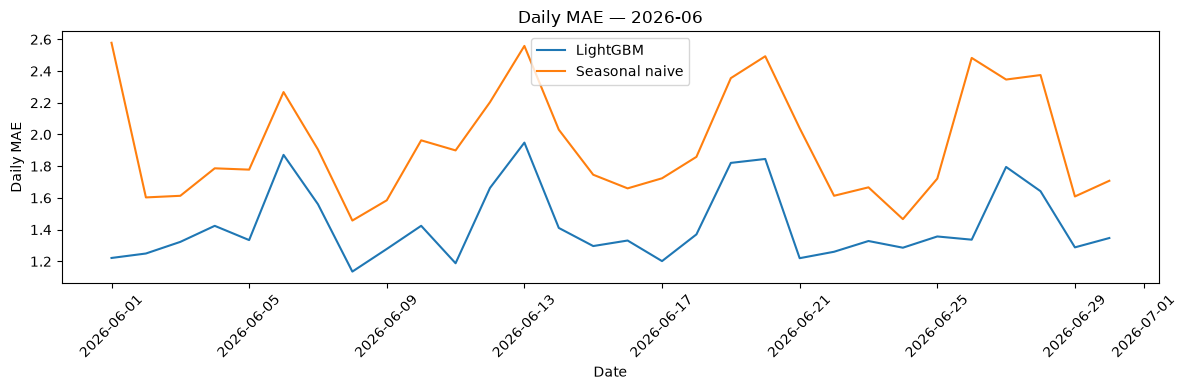

In [16]:
daily_error_pd = daily_error.sort("date").to_pandas()

plt.figure(figsize=(12, 4))
plt.plot(daily_error_pd["date"], daily_error_pd["mae_lgbm"], label="LightGBM")
plt.plot(daily_error_pd["date"], daily_error_pd["mae_naive"], label="Seasonal naive")
plt.xlabel("Date")
plt.ylabel("Daily MAE")
plt.title(f"Daily MAE — {latest_window}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Conclusion:** The highest-error days in the latest evaluation month are concentrated on high-demand June dates. The worst LightGBM day is 2026-06-13, with MAE 1.949, seasonal naive MAE 2.559, and 17,896 total trips. Other high-error days include 2026-06-06, 2026-06-20, 2026-06-19, and 2026-06-27, all with more than 14,000 total trips and LightGBM MAE above 1.79.

LightGBM still improves over seasonal naive on these difficult days, but the relative improvement varies. For example, the model reduces MAE by 23.8% on 2026-06-13, 17.5% on 2026-06-06, 26.0% on 2026-06-20, 22.7% on 2026-06-19, and 23.5% on 2026-06-27. These dates should be reviewed for missing external signals such as events, unusual weather, service disruptions, or lakefront/downtown demand shocks.

## 9. Summary of findings

### Finding 1 — LightGBM adds the most value during daytime and commute-heavy hours

Observed pattern: In the latest evaluation month, LightGBM reduces overall MAE from 1.937 to 1.425, a 26.4% improvement over seasonal naive. The strongest hourly improvements occur during the daytime and commute-heavy period. At 13:00, 14:00, 15:00, 17:00, and 12:00, LightGBM reduces MAE by 35.4%, 34.0%, 33.4%, 30.8%, and 30.4%, respectively.

Likely explanation: Seasonal naive only copies the same station-hour from the previous week, so it cannot adapt well when demand shifts due to weather, seasonality, or recent demand changes. LightGBM uses calendar, weather, station, and lag features together, which helps most during active hours when demand is higher and there is more signal to learn.

Action: Keep the current time, lag, station, and weather features. During model iteration, focus on reducing remaining peak-hour error rather than optimizing low-demand overnight periods where there is little room for improvement.

### Finding 2 — Weather features are especially valuable during rainy hours

Observed pattern: During dry hours, LightGBM reduces MAE from 1.917 to 1.447, a 24.5% improvement over seasonal naive. During rainy hours, LightGBM reduces MAE from 2.110 to 1.226, a much larger 41.9% improvement.

Likely explanation: Rain changes bikeshare demand in a way that a weekly seasonal naive baseline cannot react to. Because LightGBM has access to precipitation and other weather variables, it can adjust predictions during rainy periods.

Action: Keep weather features in the default model. On Day 4, run a no-weather experiment to quantify the exact performance loss from removing weather features. This will also estimate the risk of train/serve skew when future predictions depend on forecast weather rather than observed weather.

### Finding 3 — LightGBM under-predicts high-demand station-hours

Observed pattern: For the top 5% highest-demand station-hours, actual demand averages 13.948 trips, while LightGBM predicts 9.696 trips on average. The mean bias is -4.253 trips, meaning the model under-predicts peak demand substantially. In non-peak station-hours, the model has a smaller positive bias of +0.337 trips.

Likely explanation: LightGBM is optimized for average error, so it tends to smooth extreme spikes. High-demand spikes may also depend on external signals that are not currently included, such as major events, station disruptions, or sharp commute timing shifts.

Action: Review high-error days and high-error stations for event-driven or location-specific patterns. If the same spike days affect both LightGBM and seasonal naive, add or test event indicators on Day 4. If peak under-prediction remains large, consider reporting peak-demand slices separately from overall MAE.

### Finding 4 — The worst station errors are concentrated at high-volume lakefront and downtown stations

Observed pattern: The highest-error station is Navy Pier (`CHI01747`), with LightGBM MAE 5.612, seasonal naive MAE 8.357, and average demand of 14.026 trips per station-hour. Other high-error stations include DuSable Lake Shore Dr & North, DuSable Lake Shore Dr & Monroe, Michigan Ave & Oak St, and Theater on the Lake. These stations still show strong relative improvement over seasonal naive, often around 33–36%, but their absolute errors remain large.

Likely explanation: These are high-volume, high-variance stations near lakefront, downtown, tourist, and recreation areas. Their demand is more likely to be affected by events, tourism, weather, and non-commute behavior, which creates larger absolute forecasting errors.

Action: Use Day 4 to test whether station clustering or event indicators add value. If clustering does not improve MAE, it likely means `station_id` already captures most station-level structure. Event indicators may be more useful if high-error days align with known Chicago events.

### Finding 5 — High-error days are also high-demand days

Observed pattern: The worst LightGBM day is 2026-06-13, with MAE 1.949, seasonal naive MAE 2.559, and 17,896 total trips. Other high-error days include 2026-06-06, 2026-06-20, 2026-06-19, and 2026-06-27, all with more than 14,000 total trips and LightGBM MAE above 1.79.

Likely explanation: Error spikes are concentrated on days with larger total trip volume, so absolute MAE rises when demand is high. Since seasonal naive is also elevated on these days, the issue is likely missing external signals or unusually volatile demand rather than a LightGBM-specific failure.

Action: Review the top-error dates for events, unusual weather, or operational disruptions. If there is a clear pattern, add a small manually curated event feature on Day 4 and evaluate it through the same MLflow backtest framework.